In [22]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [24]:
# # signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

# def calculate_sig_eff_err(eff, N_gen):

#     error = math.sqrt(eff * (1 - eff) / N_gen)
#     return error

In [25]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [26]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

# MC15 full

## Acp(D+ -> eta pi+)

### eta -> gg

In [27]:
Araw_gg = 0.003504896327464449 
Araw_gg_stats_error = 0.006678776848757581

In [28]:
Aref_gg = 0.0006061306395504472 
Aref_gg_stats_error = 0.0018471929918681717

Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [29]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [30]:
Acp_etapip_gg_value

-0.0019012343120859984

In [31]:
Acp_etapip_gg_error

0.006929515289304666

### eta -> pipipi

In [32]:
Araw_pipipi =  -0.0005214333342889974  
Araw_pipipi_stats_error = 0.008951126997733127

In [33]:
Aref_pipipi = 0.0003791615573990744
Aref_pipipi_stats_error = 0.0016987754151532451

Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [34]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [35]:
Acp_etapip_pipipi_value

-0.005700594891688072

In [36]:
Acp_etapip_pipipi_error

0.009110900748042203

In [37]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

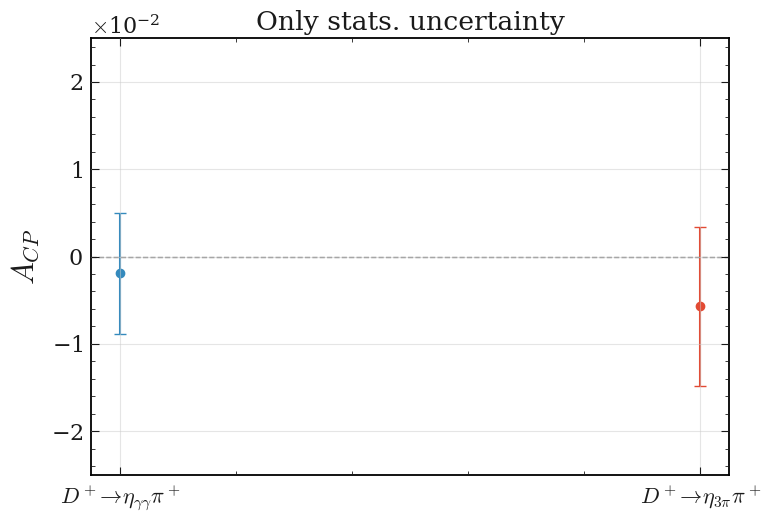

In [38]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_Kshp.png")
plt.show()

In [39]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [40]:
combined_central_value

-0.0032936100330950265

In [41]:
combined_error

0.00551549227050471

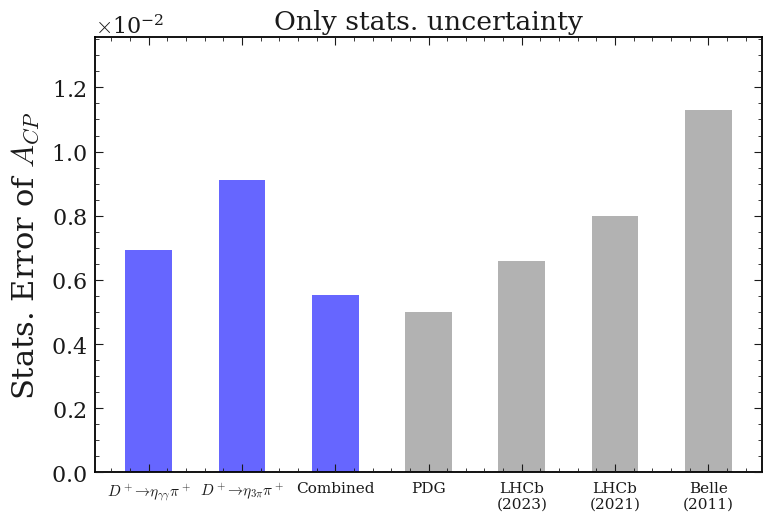

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Kshp.png")
plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [64]:
Araw_gg = 0.0015133301843937934
Araw_gg_stats_error =  0.00407564694139293

In [65]:
Aref_gg = 0.0020477180350933996
Aref_gg_stats_error = 0.0021030268194965596

Aref_gg_pdg = -0.0038
Aref_gg_pdg_sys_error = 0.0027


In [66]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [67]:
Acp_etapip_gg_value

-0.0043343878506996066

In [68]:
Acp_etapip_gg_error

0.004586242448280222

### eta -> pipipi

In [69]:
Araw_pipipi =  0.0003362131000147013
Araw_pipipi_stats_error = 0.005709802050462188

In [70]:
Aref_pipipi = 0.0020154684957205933
Aref_pipipi_stats_error = 0.0019261952673341304

Aref_pipipi_pdg = -0.0038
Aref_pipipi_pdg_sys_error = 0.0027



In [71]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [72]:
Acp_etapip_pipipi_value

-0.005479255395705892

In [73]:
Acp_etapip_pipipi_error

0.006025949523798106

In [74]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

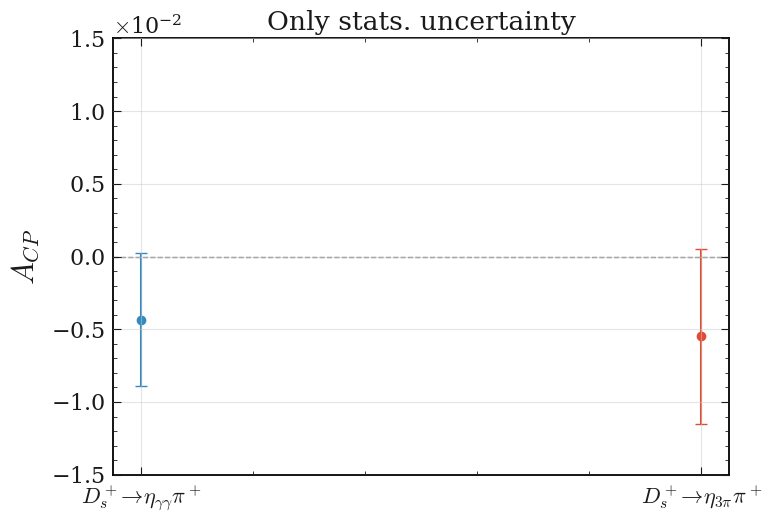

In [75]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_Phipip_Ds.png")
plt.show()

In [59]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [60]:
combined_central_value

-0.00475430972667942

In [61]:
combined_error

0.0036494894913636187

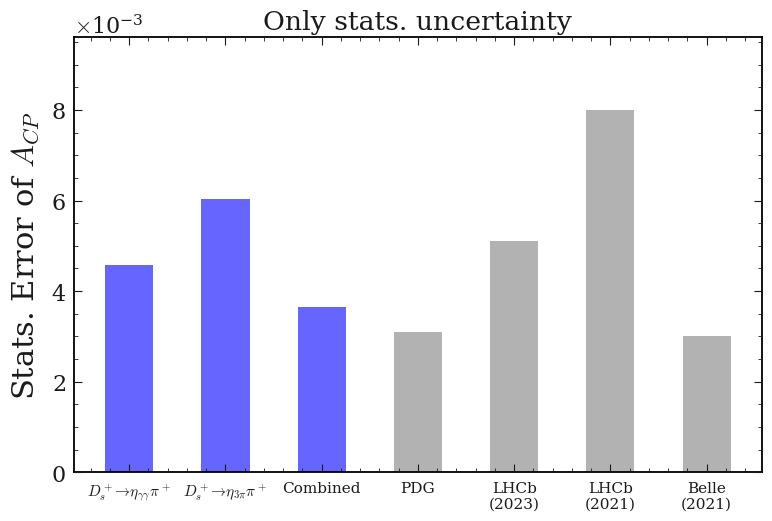

In [63]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Phipip_Ds.png")
plt.show()
